# Options Pricing & Risk Engine -- Walkthrough

A narrative tour of `optrisk`: portfolio pricing, Greeks, scenario analysis
and delta-hedging on Black-Scholes-Merton / Black-76, with binomial,
Monte Carlo and Heston stochastic-vol models layered on top.

**Contents**
1. [Pricing basics: BSM & Black-76](#1.-Pricing-basics:-BSM-&-Black-76)
2. [Greeks](#2.-Greeks)
3. [Binomial trees & Monte Carlo](#3.-Binomial-trees-&-Monte-Carlo)
4. [Building a portfolio](#4.-Building-a-portfolio)
5. [Scenario analysis: full reprice vs Taylor approximation](#5.-Scenario-analysis:-full-reprice-vs-Taylor-approximation)
6. [Delta-hedging simulation](#6.-Delta-hedging-simulation)
7. [Heston stochastic volatility & the vol smile](#7.-Heston-stochastic-volatility-&-the-vol-smile)

In [1]:
import numpy as np
import pandas as pd

from optrisk.models.black_scholes import bsm_price
from optrisk.models.black76 import black76_price
from optrisk.models.implied_vol import bsm_implied_vol
from optrisk.models.binomial import crr_price
from optrisk.models.monte_carlo import mc_price
from optrisk.models.heston import heston_price, heston_implied_vol_smile
from optrisk.greeks.analytical import bsm_greeks, bsm_full_greeks
from optrisk.instruments.option import MarketEnv, OptionSpec, Stock
from optrisk.instruments.portfolio import Portfolio, Position
from optrisk.market.sample_data import build_demo_portfolio
from optrisk.risk.scenarios import default_shock_grid, run_scenario_analysis, TAYLOR_ORDERS, TAYLOR_ORDER_LABELS
from optrisk.risk.hedging import simulate_delta_hedge, run_hedge_frequency_comparison
from optrisk.viz.plots import (
    plot_payoff_diagram, plot_greek_curves, plot_greeks_bar, plot_pnl_heatmap,
    plot_taylor_error_heatmaps, plot_taylor_slice, plot_hedge_path,
    plot_hedge_pnl_distribution, plot_vol_smile,
)

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 1. Pricing basics: BSM & Black-76

Black-Scholes-Merton prices European options on an equity with a continuous
dividend yield; Black-76 prices European options on a forward/futures price.
Both satisfy put-call parity exactly, and Black-76 on `F = S*e^(r-q)T`
reproduces the BSM price exactly -- the two models are cross-validated
against each other in `tests/test_black76.py`.

In [2]:
spot, strike, rate, div_yield, vol, expiry = 100.0, 105.0, 0.04, 0.015, 0.28, 0.5

call = bsm_price(spot, strike, rate, div_yield, vol, expiry, "call")
put = bsm_price(spot, strike, rate, div_yield, vol, expiry, "put")
parity_check = (call - put) - (spot * np.exp(-div_yield * expiry) - strike * np.exp(-rate * expiry))

print(f"BSM call = {call:.4f}   BSM put = {put:.4f}")
print(f"put-call parity residual (should be ~0): {parity_check:.2e}")

forward = spot * np.exp((rate - div_yield) * expiry)
b76_call = black76_price(forward, strike, rate, vol, expiry, "call")
print(f"Black-76 call on the equivalent forward F={forward:.3f}: {b76_call:.4f}  (BSM: {call:.4f})")

BSM call = 6.2705   BSM put = 9.9386
put-call parity residual (should be ~0): 0.00e+00
Black-76 call on the equivalent forward F=101.258: 6.2705  (BSM: 6.2705)


In [3]:
# implied volatility solver: round-trip a price back to the vol that produced it
recovered_vol = bsm_implied_vol(call, spot, strike, rate, div_yield, expiry, "call")
print(f"true vol = {vol:.4f}   recovered implied vol = {recovered_vol:.4f}")

true vol = 0.2800   recovered implied vol = 0.2800


## 2. Greeks

Closed-form Delta/Gamma/Vega/Theta/Rho/Vanna/Volga, plus Charm/Speed/Zomma/Color from the finite-difference engine.

In [4]:
greeks = bsm_full_greeks(spot, strike, rate, div_yield, vol, expiry, "call")
pd.Series(greeks.as_dict(), name="ATM-ish call Greeks").to_frame()

,ATM-ish call Greeks
delta,0.463
gamma,0.020
vega,27.899
theta,-8.718
rho,20.011
vanna,0.398
volga,2.371
charm,-0.154
speed,-0.000
zomma,-0.069


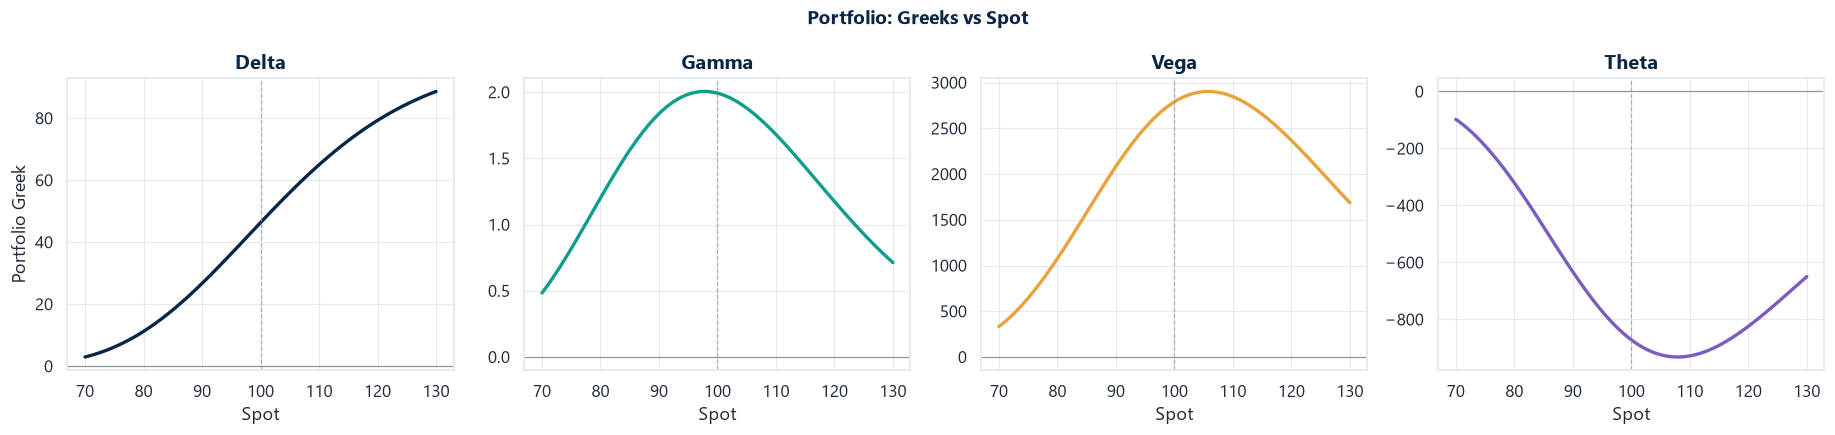

In [5]:
demo_portfolio_preview = Portfolio(positions=[Position(
    instrument=OptionSpec("call", strike, expiry, "european", "equity"),
    quantity=1, market=MarketEnv(spot, rate, vol, div_yield), multiplier=100,
)])
fig = plot_greek_curves(demo_portfolio_preview, greek_names=("delta", "gamma", "vega", "theta"))

## 3. Binomial trees & Monte Carlo

The CRR binomial tree prices American options (early-exercise premium);
as steps grow, its European price converges to BSM. The Monte Carlo engine
(antithetic + control variate) independently validates the same price.

In [6]:
style_compare = pd.DataFrame({
    "steps": [50, 200, 800],
    "european_binomial": [crr_price(spot, strike, rate, div_yield, vol, expiry, "put", "european", s) for s in (50, 200, 800)],
})
style_compare["bsm_reference"] = bsm_price(spot, strike, rate, div_yield, vol, expiry, "put")
style_compare["american_binomial"] = [crr_price(spot, strike, rate, div_yield, vol, expiry, "put", "american", s) for s in (50, 200, 800)]
style_compare["early_exercise_premium"] = style_compare["american_binomial"] - style_compare["european_binomial"]
style_compare

,steps,european_binomial,bsm_reference,american_binomial,early_exercise_premium
0,50,9.934,9.939,10.117,0.184
1,200,9.943,9.939,10.124,0.181
2,800,9.941,9.939,10.121,0.180


In [7]:
mc_result = mc_price(spot, strike, rate, div_yield, vol, expiry, "call", n_paths=200_000, seed=7)
print(f"Monte Carlo: {mc_result.price:.4f} +/- {mc_result.std_error:.4f} (1 s.e., {mc_result.n_paths:,} paths)")
print(f"BSM closed-form: {call:.4f}")
print(f"difference in standard errors: {abs(mc_result.price - call) / mc_result.std_error:.2f}")

Monte Carlo: 6.2526 +/- 0.0134 (1 s.e., 200,000 paths)
BSM closed-form: 6.2705
difference in standard errors: 1.33


## 4. Building a portfolio

`build_demo_portfolio()` assembles a small multi-underlying book: a call
spread and a protective-put tail hedge on a fictitious equity ("TECH"), a
futures option on a fictitious commodity ("CRUDE"), and a partial delta
hedge in the stock -- enough genuine convexity to make the risk analyses
below non-trivial.

In [8]:
portfolio = build_demo_portfolio()
display(portfolio.to_frame()[["label", "quantity", "price", "value", "delta", "gamma", "vega", "theta"]])
print(f"\nPortfolio value: ${portfolio.value():,.2f}")

,label,quantity,price,value,delta,gamma,vega,theta
0,TECH 185C 3M,10,11.128,"11,128.431",553.010,15.231,"36,489.057","-23,718.449"
1,TECH 210C 3M,-15,3.069,"-4,602.753",-330.625,-17.152,"-41,092.499","25,067.807"
2,TECH 160P 6M (Am),20,3.909,"7,818.505",-357.189,21.021,"66,593.503","-16,155.496"
3,TECH 185P 6M,-5,12.771,"-6,385.558",211.005,-5.325,"-25,512.820","5,411.911"
4,CRUDE 82C 4M (Fut),2,4.535,"9,069.402",869.178,49.579,"34,839.573","-18,067.408"
5,TECH shares (partial hedge),-75,185.000,"-13,875.000",-75.000,-0.000,-0.000,-0.000



Portfolio value: $3,153.03


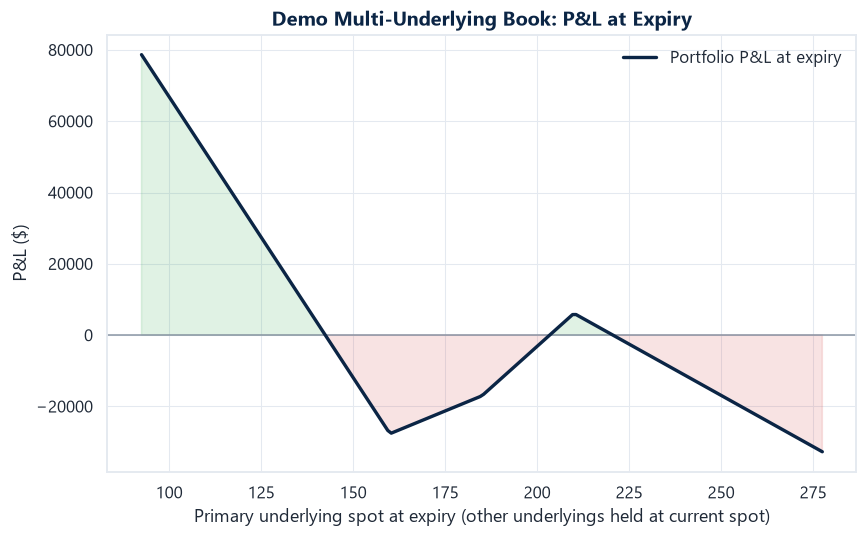

In [9]:
fig = plot_payoff_diagram(portfolio)

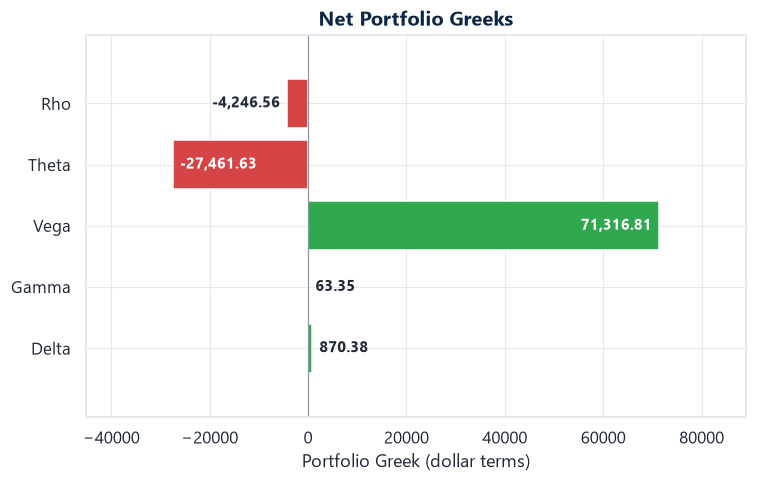

In [10]:
fig = plot_greeks_bar(portfolio.greeks())

## 5. Scenario analysis: full reprice vs Taylor approximation

This is the core risk analysis: reprice the whole book exactly across a
grid of spot/vol shocks, then compare against Taylor-series approximations
built only from the base-case Greeks. The gap between them **is** the
nonlinear risk a Greeks-only view misses.

In [11]:
spot_shocks, vol_shocks = default_shock_grid(spot_range_pct=0.25, n_spot=41, vol_range=0.15, n_vol=31)
result = run_scenario_analysis(portfolio, spot_shocks, vol_shocks)

for order in TAYLOR_ORDERS:
    print(f"{TAYLOR_ORDER_LABELS[order]:<32s} max |error| = ${result.max_abs_error(order):,.0f}")

Delta only                       max |error| = $40,760
Delta + Gamma                    max |error| = $20,083
Delta + Gamma + Vega             max |error| = $29,336
Full 2nd order (+ Vanna/Volga)   max |error| = $31,812


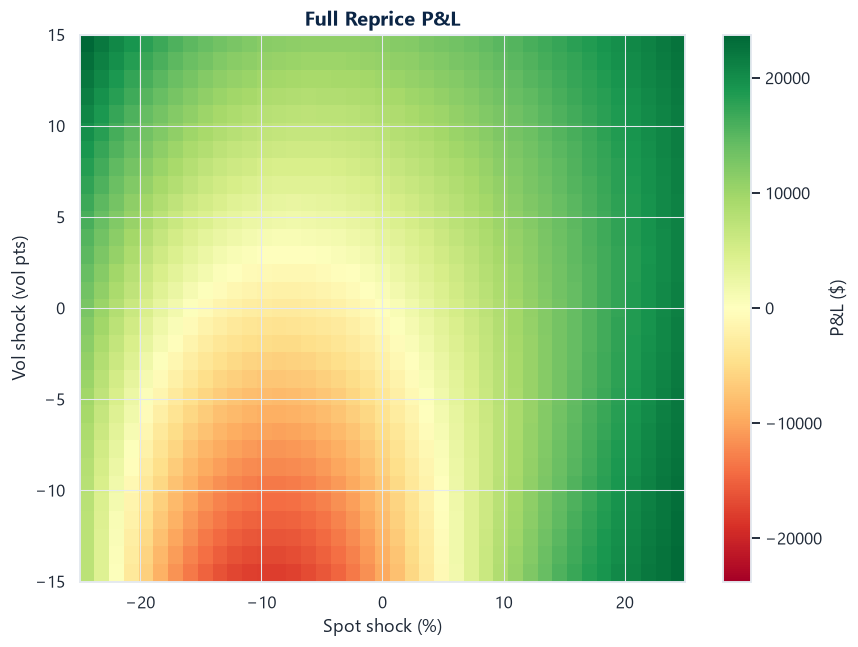

In [12]:
fig = plot_pnl_heatmap(result)

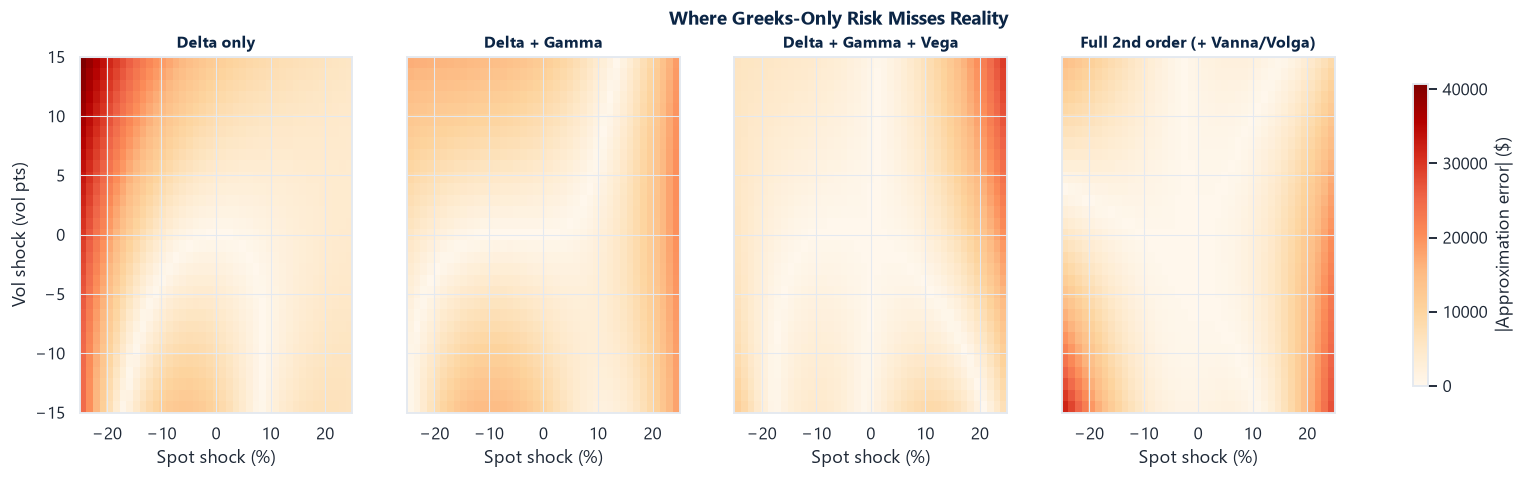

In [13]:
fig = plot_taylor_error_heatmaps(result)

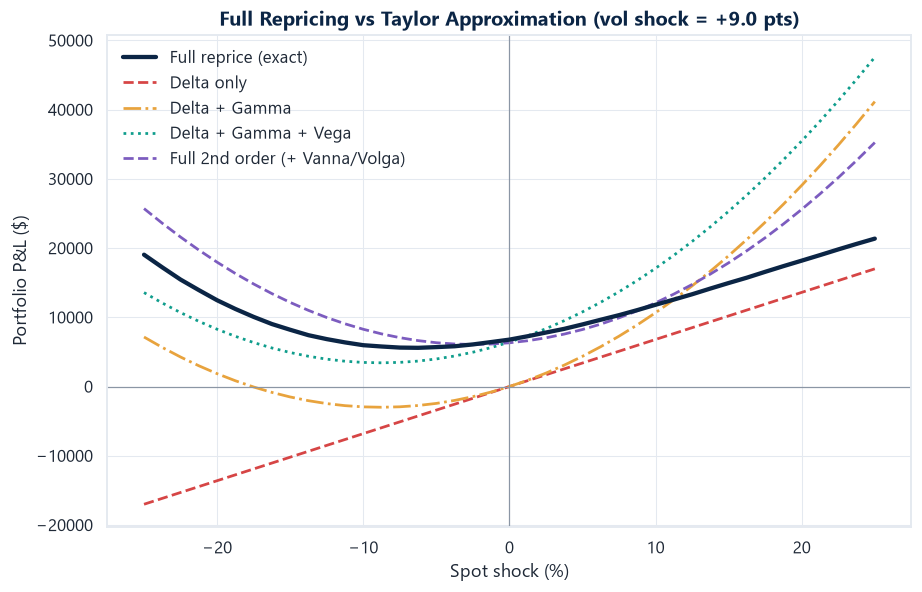

In [14]:
# slice at a meaningfully nonzero vol shock so Vega/Vanna/Volga actually differentiate the curves
hero_idx = int(0.83 * (len(vol_shocks) - 1))
fig = plot_taylor_slice(result, vol_shock_index=hero_idx)

## 6. Delta-hedging simulation

Delta-hedge an option through expiry when the *realized* volatility of the
underlying differs from the *implied* volatility used to hedge. The
textbook relationship:

$$d\text{PnL} \approx q \cdot \tfrac{1}{2}\,\Gamma\, S^2 \,(\sigma_{realized}^2 - \sigma_{implied}^2)\, dt$$

says a long-gamma position (long the option, $q=+1$) profits when the
world moves *more* than it was hedged for.

final hedging P&L on this path: +0.536


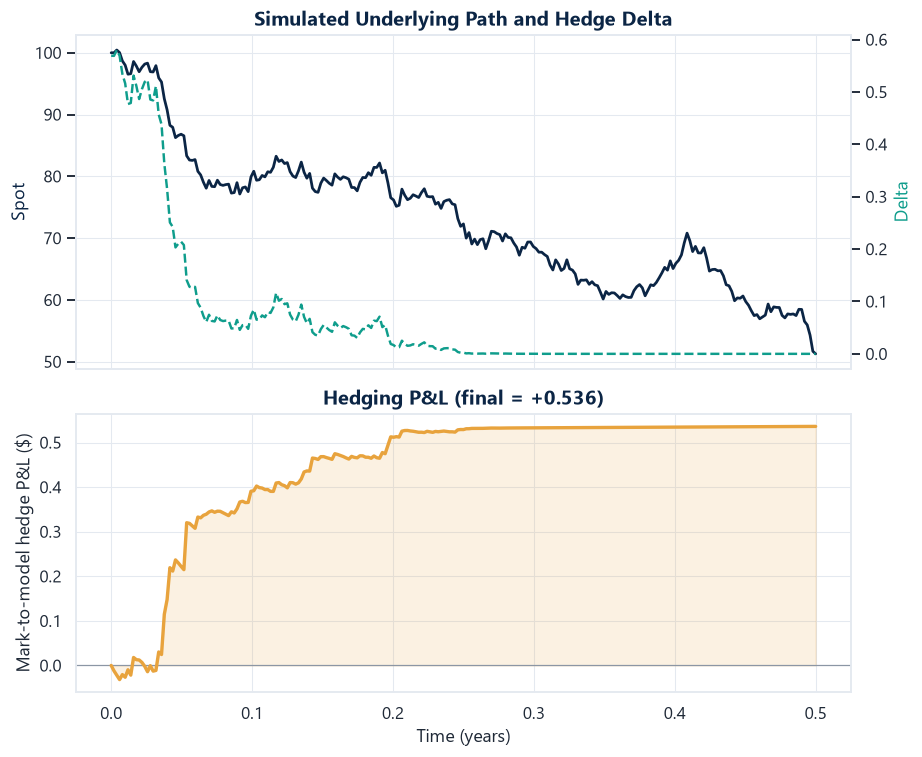

In [15]:
hedge_result = simulate_delta_hedge(
    spot0=100.0, strike=100.0, rate=0.03, dividend_yield=0.0,
    implied_vol=0.22, realized_vol=0.34, expiry=0.5, option_type="call",
    option_quantity=1.0, n_steps=252, seed=7,
)
print(f"final hedging P&L on this path: {hedge_result.final_pnl:+.3f}")
fig = plot_hedge_path(hedge_result)

,mean,std
frequency,,
Daily,3.256,1.660
Monthly,3.239,2.630
Quarterly,3.563,4.110
Weekly,3.241,2.096


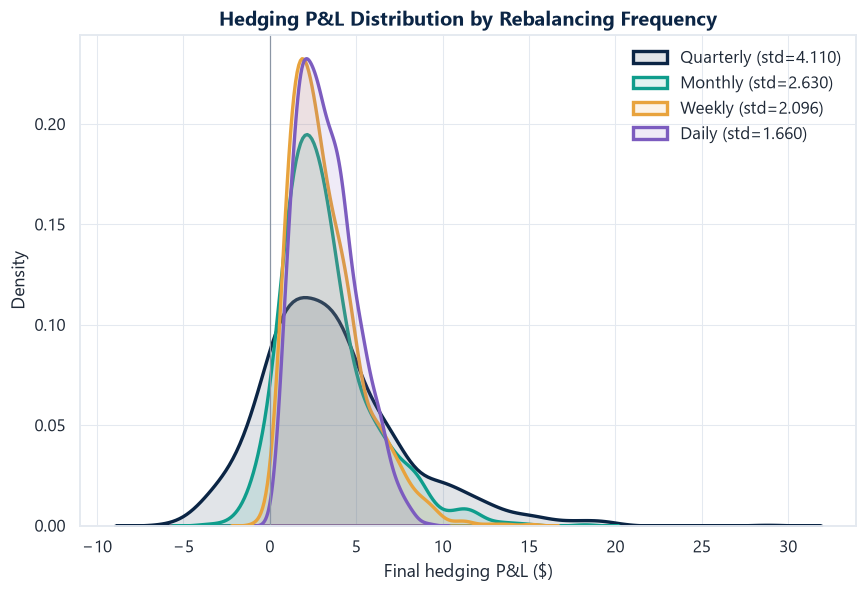

In [16]:
freq_frame = run_hedge_frequency_comparison(
    spot0=100.0, strike=100.0, rate=0.03, dividend_yield=0.0,
    implied_vol=0.22, realized_vol=0.34, expiry=0.5, option_type="call",
    frequencies={"Daily": 252, "Weekly": 36, "Monthly": 12, "Quarterly": 4},
    n_paths=1000, seed=7,
)
display(freq_frame.groupby("frequency")["final_pnl"].agg(["mean", "std"]))
fig = plot_hedge_pnl_distribution(freq_frame)

## 7. Heston stochastic volatility & the vol smile

BSM assumes one flat volatility for every strike. Real markets show a
skew/smile. Heston models volatility itself as a mean-reverting random
process, priced here via the Fang-Oosterlee COS method (a Fourier-cosine
series inversion of the characteristic function, not Monte Carlo) -- and
that alone is enough to reproduce a realistic skew.

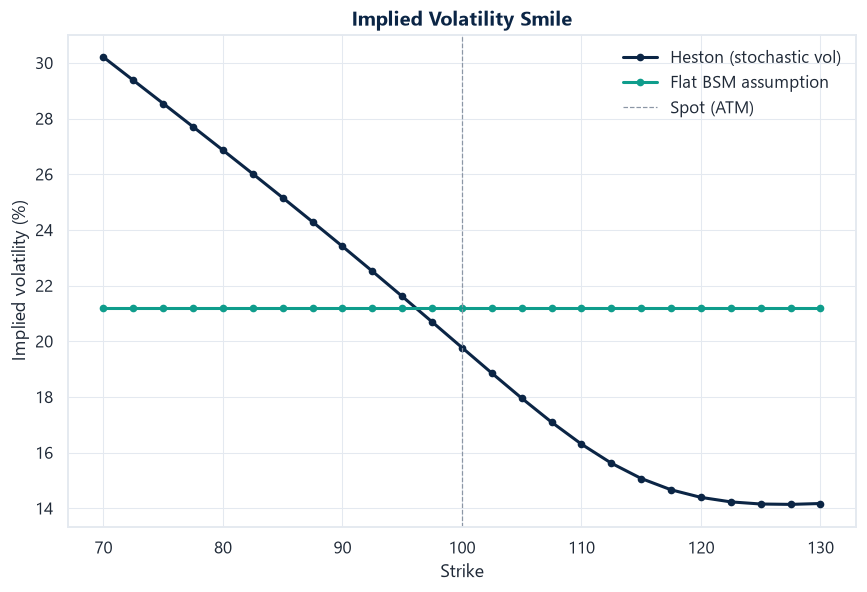

In [17]:
strikes = np.linspace(70, 130, 25)
heston_ivs = heston_implied_vol_smile(
    spot=100.0, rate=0.03, dividend_yield=0.0, expiry=0.5,
    v0=0.045, kappa=1.8, theta=0.045, xi=0.55, rho=-0.75,
    strikes=strikes, option_type="call",
)
flat_bsm = np.full_like(strikes, np.sqrt(0.045))
fig = plot_vol_smile(strikes, {"Heston (stochastic vol)": heston_ivs, "Flat BSM assumption": flat_bsm}, spot=100.0)

## Summary

- **Pricing**: BSM, Black-76, CRR binomial (American exercise), Monte Carlo
  (variance-reduced), and Heston (COS method) -- cross-validated against
  each other rather than against memorized reference numbers.
- **Greeks**: closed-form 1st/2nd order plus a finite-difference engine for
  3rd-order Greeks and for models without closed forms.
- **Portfolio & scenario analysis**: full repricing vs increasingly rich
  Taylor approximations quantifies exactly how much nonlinear risk a
  Greeks-only view misses.
- **Delta-hedging**: simulated P&L under realized-vs-implied vol mismatch
  ties the scenario-analysis story directly to a trading P&L outcome.

See the [README](../README.md) for the full architecture and the
`app/dashboard.py` Streamlit app for an interactive version of everything above.